In [ ]:
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

--2026-05-24 20:27:50--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.216.207, 108.177.12.207, 74.125.26.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.216.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   217MB/s    in 0.5s    

2026-05-24 20:27:50 (217 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



In [ ]:
#Unzip the downloaded file
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

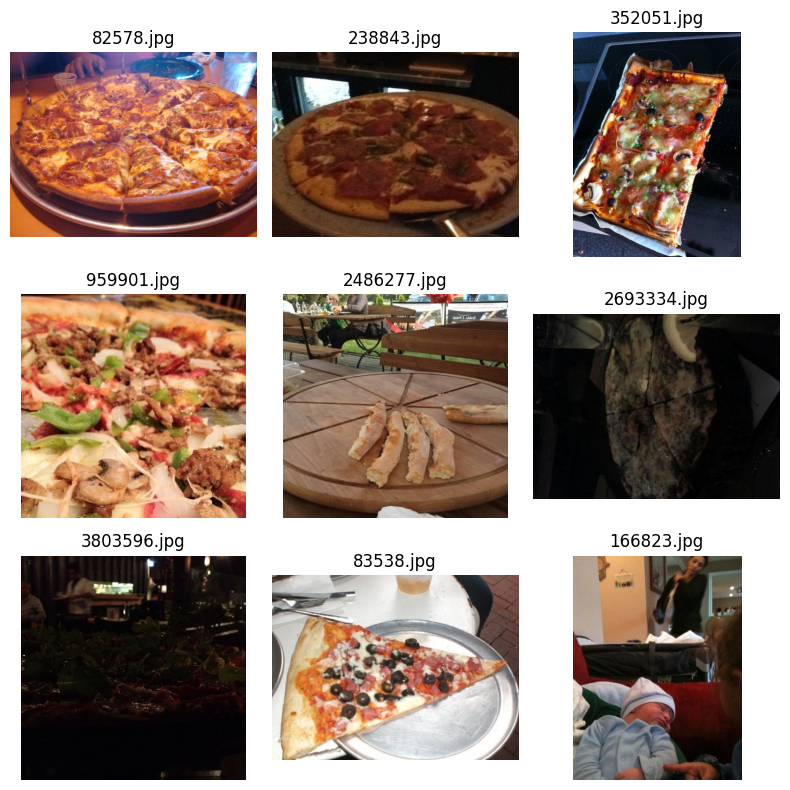

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

folder_path = "pizza_steak/train/pizza"

images = os.listdir(folder_path)[:9]

plt.figure(figsize=(8, 8))

for i, image_name in enumerate(images):
    img_path = os.path.join(folder_path, image_name)
    img = mpimg.imread(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_name)

plt.tight_layout()
plt.show()

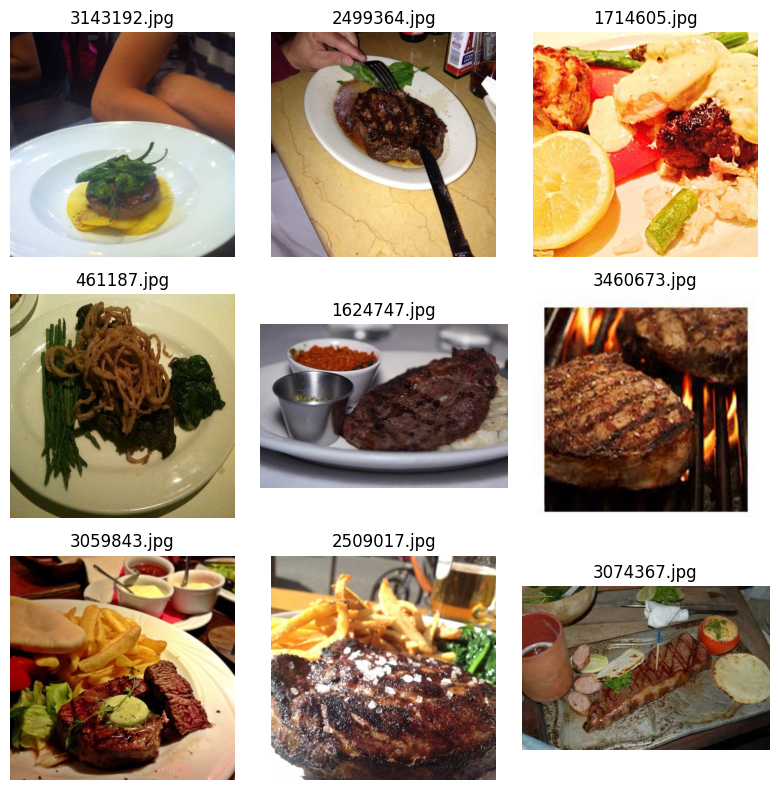

In [ ]:
folder_path = "pizza_steak/train/steak"

images = os.listdir(folder_path)[:9]

plt.figure(figsize=(8, 8))

for i, image_name in enumerate(images):
    img_path = os.path.join(folder_path, image_name)
    img = mpimg.imread(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_name)

plt.tight_layout()
plt.show()

The images we're working with from the Food101 dataset (101 different classes of food): https://www.kaggle.com/datasets/dansbecker/food-101  

However we've modified it to only use two classes (pizza 🍕 & steak 🍖) using the image data modification notebook : https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb   



## Inspect the data

In [ ]:
!ls pizza_steak

test  train


In [ ]:
!ls pizza_steak/train/

pizza  steak


In [ ]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [ ]:
for diepath, dirnames, filenames in os.walk("pizza_steak"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{diepath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak/train'.
There are 0 directories and 750 images in 'pizza_steak/train/pizza'.
There are 0 directories and 750 images in 'pizza_steak/train/steak'.
There are 2 directories and 0 images in 'pizza_steak/test'.
There are 0 directories and 250 images in 'pizza_steak/test/pizza'.
There are 0 directories and 250 images in 'pizza_steak/test/steak'.


In [ ]:
!ls -la pizza_steak

total 16
drwxr-xr-x 4 root root 4096 May 24 17:58 .
drwxr-xr-x 1 root root 4096 May 24 17:58 ..
drwxr-xr-x 4 root root 4096 May 24 17:58 test
drwxr-xr-x 4 root root 4096 May 24 17:58 train


Another way to find out how many images are in a file

In [ ]:
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))
num_steak_images_train

750

In [ ]:
num_pizza_images_train = len(os.listdir("pizza_steak/train/pizza"))
num_pizza_images_train

750

To visualize our images, first let's get the class names programmatically.

In [ ]:
import pathlib
import numpy as np

data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")]))
print(class_names)

['pizza' 'steak']


In [ ]:
import random
def view_random_image(target_dir, target_class):
  # Setup the target directory (we'll view images from here)
  target_folder = target_dir + target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)
  print(random_image)

  #Read in the image and plot it using matpllotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}")

  return img

['1598345.jpg']
Image shape: (343, 512, 3)


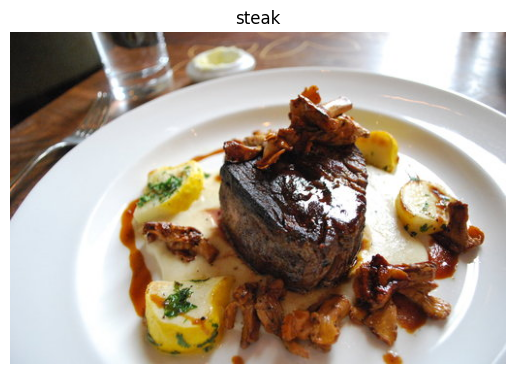

In [ ]:
img = view_random_image(target_dir="pizza_steak/train/",
                        target_class="steak")

Note: Some images in the dataset may contain label noise, meaning the folder label and the actual image content may not always match. For example, an image labeled as “steak” might not actually contain steak. A small amount of label noise is usually tolerable, but too many mislabeled images can negatively affect model training.

In [ ]:
print(img)

[[[ 17  12  16]
  [ 20  15  19]
  [ 19  14  18]
  ...
  [ 96  94  95]
  [ 95  93  94]
  [ 92  90  91]]

 [[ 15  10  14]
  [ 18  13  17]
  [ 17  12  16]
  ...
  [100  98  99]
  [100  98  99]
  [ 97  95  96]]

 [[ 13   8  12]
  [ 15  10  14]
  [ 15  10  14]
  ...
  [102 100 101]
  [102 100 101]
  [100  98  99]]

 ...

 [[ 19  18  24]
  [ 19  18  24]
  [ 19  18  24]
  ...
  [ 31  30  28]
  [ 30  29  27]
  [ 30  29  27]]

 [[ 18  17  23]
  [ 18  17  23]
  [ 19  18  24]
  ...
  [ 33  32  30]
  [ 33  32  30]
  [ 32  31  29]]

 [[ 18  17  23]
  [ 18  17  23]
  [ 19  18  24]
  ...
  [ 30  28  29]
  [ 29  27  28]
  [ 28  26  27]]]


In [ ]:
img.dtype, type(img)

(dtype('uint8'), numpy.ndarray)

An RGB image is stored as a NumPy ndarray with shape (height, width, 3).
Each pixel contains three values: [R, G, B].
The dtype is often uint8, meaning pixel values are integers between 0 and 255.

In [ ]:
import tensorflow as tf

tf.constant(img)

<tf.Tensor: shape=(343, 512, 3), dtype=uint8, numpy=
array([[[ 21,  20,  16],
        [ 23,  22,  18],
        [ 24,  23,  19],
        ...,
        [144, 124, 117],
        [121, 101,  92],
        [109,  86,  78]],

       [[ 22,  21,  17],
        [ 23,  22,  18],
        [ 23,  22,  18],
        ...,
        [146, 125, 120],
        [124, 104,  97],
        [112,  89,  83]],

       [[ 24,  23,  19],
        [ 23,  22,  18],
        [ 22,  21,  17],
        ...,
        [145, 126, 120],
        [124, 105,  98],
        [112,  92,  85]],

       ...,

       [[198, 210, 222],
        [199, 211, 223],
        [200, 212, 224],
        ...,
        [190, 200, 210],
        [190, 198, 209],
        [190, 198, 209]],

       [[198, 210, 222],
        [198, 210, 222],
        [199, 211, 223],
        ...,
        [188, 198, 208],
        [188, 196, 207],
        [187, 195, 206]],

       [[197, 209, 221],
        [198, 210, 222],
        [199, 211, 223],
        ...,
        [188, 198, 20

I did not manually split the image into RGB pixel values.   
The function mpimg.imread() reads the image file, decodes it, and converts it into a NumPy array.   
For an RGB image, each pixel is represented by three values: [R, G, B].

In [ ]:
img.shape

(333, 512, 3)

In [ ]:
# Get all pixel values between 0 & 1
img / 255.

array([[[0.06666667, 0.04705882, 0.0627451 ],
        [0.07843137, 0.05882353, 0.0745098 ],
        [0.0745098 , 0.05490196, 0.07058824],
        ...,
        [0.37647059, 0.36862745, 0.37254902],
        [0.37254902, 0.36470588, 0.36862745],
        [0.36078431, 0.35294118, 0.35686275]],

       [[0.05882353, 0.03921569, 0.05490196],
        [0.07058824, 0.05098039, 0.06666667],
        [0.06666667, 0.04705882, 0.0627451 ],
        ...,
        [0.39215686, 0.38431373, 0.38823529],
        [0.39215686, 0.38431373, 0.38823529],
        [0.38039216, 0.37254902, 0.37647059]],

       [[0.05098039, 0.03137255, 0.04705882],
        [0.05882353, 0.03921569, 0.05490196],
        [0.05882353, 0.03921569, 0.05490196],
        ...,
        [0.4       , 0.39215686, 0.39607843],
        [0.4       , 0.39215686, 0.39607843],
        [0.39215686, 0.38431373, 0.38823529]],

       ...,

       [[0.0745098 , 0.07058824, 0.09411765],
        [0.0745098 , 0.07058824, 0.09411765],
        [0.0745098 , 0

## An end-to-end example

Let's build a convolutional neural network to find patterns in our images, more specifially we a need way to:  

*Load our images  
*Preprocessing our images  
*Build a CNN to find patterns in our images  
*Compile our CNN  
*Fit the CNN to our training data  

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

#Preprocessing data
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

#Setup paths
train_dir = "/content/pizza_steak/train"
test_dir = "/content/pizza_steak/test"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)
valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)
# Build a CNN model (same as the Tiny VGG on the CNN explainer website)
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation="relu",
                           input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding="valid"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model_1.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history_1 = model_1.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=valid_data,
    validation_steps=len(valid_data)
)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.6553 - loss: 0.6450 - val_accuracy: 0.6480 - val_loss: 0.6039
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.7480 - loss: 0.5237 - val_accuracy: 0.8380 - val_loss: 0.4075
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.7960 - loss: 0.4529 - val_accuracy: 0.8540 - val_loss: 0.3912
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.8087 - loss: 0.4260 - val_accuracy: 0.8400 - val_loss: 0.3501
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.8313 - loss: 0.3870 - val_accuracy: 0.8460 - val_loss: 0.3448


In [ ]:
len(train_data)

In [ ]:
1500 / 32

### with CPU
Found 1500 images belonging to 2 classes.  
Found 500 images belonging to 2 classes.  
Epoch 1/5  
47/47 ━━━━━━━━━━━━━━━━━━━━ **111s 2ms**/step

### with GPU
Epoch 1/5  
47/47 ━━━━━━━━━━━━━━━━━━━━ **18s 241ms**/step

In [ ]:
model_1.summary()

Link to exercise CNN :  

https://poloclub.github.io/cnn-explainer/

Let's replicate the model in [TensorFlow playgorund](https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.001&regularizationRate=0&noise=0&networkShape=4,4&seed=0.76654&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) to look at if it's working our image data

In [ ]:
train_data

In [ ]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model_2.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history_2 = model_2.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=valid_data,
    validation_steps=len(valid_data)
)

In [ ]:
model_2.summary()

Despite having 20x parameters than our CNN (model_1), model_2 performs terribly...let's try to improve it.

In [ ]:
tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model_3.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history_3 = model_3.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=valid_data,
    validation_steps=len(valid_data)
)

In [ ]:
model_3.summary()

In [ ]:
15073201 / 31101

⚡ **Note :** You can think of trainable parameters as patterns a model can learn from data.Intuitively, you might think more is better.And in lotf of cases, it is.But in this case, the difference here is the two different styles of model we're using.Where a series of dense layers has a number of different learnable parameters connected to each other and hence a higher number of possible learnable patterns, **a convolutional neural network seeks to sort out and learn the most important patterns in an image.**So even though these are less learnable parameters in our convolutional neural network, these are often more helpful in dechiphering between different **features** in an image.

## Binary Classification : Let's break it down

1. Become one with the data (visualize, visualize, visualize)  
2. Preprocessing the data (prepared it for our model, the main step here was scaling/normalizing and turning our data into batches.  
3. Create a model (start with a baseline)  
4. Fit the model  
5. Evaluate the model  
6. Adjust different parameters and improve the model (try to beat our baseline)  
7. Repeat untill satisfied (experiment, experiment, experiment)  


### 1. Become with the data

In [ ]:
plt.figure()
plt.subplot(1, 2, 1)
steak_img = view_random_image("pizza_steak/train/", "steak")
plt.subplot(1, 2, 2)
pizza_img = view_random_image("pizza_steak/train/", "pizza")

### 2. Preprocessing the data

In [ ]:
# Define directory dataset paths
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

Turn our data into **batches**.  

A batch is a small subset of data.Rather than look at all ~10,000 images at one time, a model might only look at 32 at a time (memory issue).  

It does this for a couple of reasons:
1. 10.000 images (or more) might not fit into the memory of your processor (GPU).  
2. Trying to learn the patterns in 10,000 images in one hit could result in the model not being able to learn very well.  
Why 32 ?   
Because 32 is good for your health :)))  


In [ ]:
!nvidia-smi

In [ ]:
# Create train and test data generators and rescale the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

In [ ]:
# Load in our image data from directories and turn them into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               batch_size=32)
test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224, 224),
                                             class_mode="binary",
                                             batch_size=32)


Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [ ]:
# Get a sample of a train data batch
images, labels = next(train_data)

len(images), len(labels)

(32, 32)

In [ ]:
# Get the first two images
images[:2], images[0].shape

(array([[[[0.23529413, 0.21568629, 0.14117648],
          [0.2509804 , 0.22352943, 0.14901961],
          [0.26666668, 0.22352943, 0.15294118],
          ...,
          [0.47058827, 0.4156863 , 0.3137255 ],
          [0.47450984, 0.4156863 , 0.33333334],
          [0.4156863 , 0.35686275, 0.28235295]],
 
         [[0.24313727, 0.22352943, 0.14901961],
          [0.24705884, 0.21960786, 0.14509805],
          [0.24705884, 0.20392159, 0.13333334],
          ...,
          [0.48627454, 0.427451  , 0.3372549 ],
          [0.47450984, 0.4156863 , 0.33333334],
          [0.47058827, 0.40784317, 0.34509805]],
 
         [[0.2509804 , 0.23137257, 0.15686275],
          [0.26666668, 0.2392157 , 0.16862746],
          [0.23529413, 0.20392159, 0.12941177],
          ...,
          [0.4666667 , 0.4156863 , 0.34117648],
          [0.4666667 , 0.4156863 , 0.34901962],
          [0.48235297, 0.43137258, 0.36862746]],
 
         ...,
 
         [[0.46274513, 0.43921572, 0.38431376],
          [0.46274

In [ ]:
# View the first batch of labels
labels

array([1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1.,
       1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1.],
      dtype=float32)

### 3. Create a CNN model (start with a baseline)  

A baseline is a relatively simple model or existing result that you setup when beginning a machine learning experiment and then as you keep exprementing, you try to beat the baseline.  

✈ **Note :** In deep learning, there is alomst an infinite amount of architectures you could create.So one of the best waysto get started is to start with something simple and see if it works on your data and then introduce complexity as required (e.g. look which current model is preforming best in the field for your problem).  


https://poloclub.github.io/cnn-explainer/

In [ ]:
# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

In [ ]:
# Create the model (this will be our baseline, a layer convolutional neural network)
model_4 = Sequential([
   Conv2D(filters=10,
          kernel_size=3,
          strides=1,
          padding="valid",
          activation="relu",
          input_shape=(224, 224, 3)), #input layer
   Conv2D(10 , 3, activation="relu"),
   Conv2D(10, 3, activation="relu"),
   Flatten(),
   Dense(1, activation="sigmoid") #output layer
])


In [ ]:
# Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

In [ ]:
model_4.summary()

### 4. Fit the model

In [ ]:
history_4 = model_4.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

In [ ]:
model_1.evaluate(test_data)

In [ ]:
model_1.summary()

### 5. Evaluate our **model**

It looks like our model is learning something, let's evaluate it.

In [ ]:
# Let's plotting oour training curves
import pandas as pd
pd.DataFrame(history_4.history).plot(figsize=(10, 7))

NameError: name 'history_4' is not defined

In [ ]:
# Plot the validation and training curves seperately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]

  epochs = range(len(history.history["loss"]))

  # Plot loss
  plt.plot(epochs, loss, label="training_loss")
  plt.plot(epochs, val_loss, label="val_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label="training_accuracy")
  plt.plot(epochs, val_accuracy, label="val_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

In [ ]:
 plot_loss_curves(history_4)

⚓ **Note :** When a model's **validation loss** starts to increase, it's likely that the model is **overfitting** the training dataset.This means it's learning the patterns in the training dataset **too well** and thus the model's ability to generalize to unseen data will be diminished.  

### 6. Adjust the model parameters

Fitting a machine learning model comes in 3 steps:

0. Create a baseline  
1. Beat the baseline by overfitting a larger model  
2. Reduce overfitting  

Ways to induce overfitting:

* Increase the number of conv layers  
* Increase the number of filters  
* Add another dense layer to the output of our flattened layer  

Reduce overfitting:

* Add data augmentation
* Add regularization layers (such as MaxPool2D)
* Add more data...

⛹ **Note :** Reducing overfitting is also known as **regularization**.

In [ ]:
# Create the model (this is going to be our new baseline)
model_5 = Sequential([
    Conv2D(10, 3, activation="relu" ,input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=2),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(), # default (2,2) basicly 2
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

In [ ]:
# help(tf.keras.layers.MaxPool2D)

In [ ]:
model_5.compile(
    loss="binary_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

In [ ]:
history_5 = model_5.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=len(test_data)
)

In [ ]:
model_5.summary()

In [ ]:
plot_loss_curves(history_5)

### Opening our bag of tricks and finding data augmentation

In [ ]:
# Create ImageDataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0.2,
                                             shear_range=0.2,
                                             zoom_range=0.2,
                                             width_shift_range=0.2,
                                             height_shift_range=0.3,
                                             horizontal_flip=True)

# Create ImageDataGenerator test instance without data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.)

# Create ImageDataGenerator without data augmentation for the test dataset
test_datagen = ImageDataGenerator(rescale=1/255.)

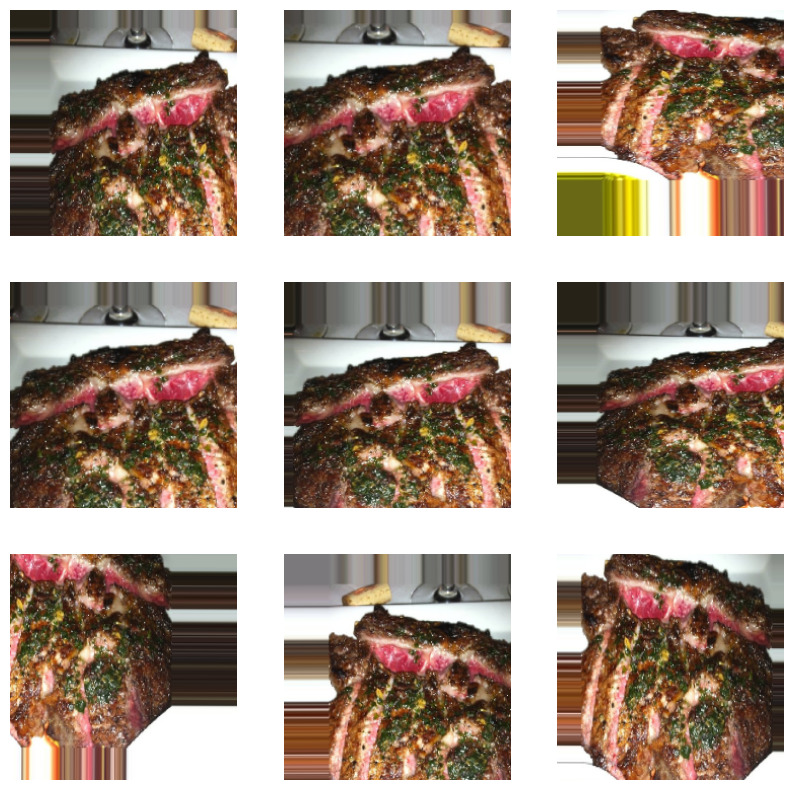

In [ ]:
images, labels = next(train_data)

image = images[0]

plt.figure(figsize=(10, 10))

for i in range(9):
    augmented_batch = train_datagen_augmented.random_transform(image)

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_batch)
    plt.axis("off")

⛵ **Question :** What is data augmentation?

Data augmentation is the process of altering our traning data, leading it to have more diversity and in turn allowing our models to learn more generalizable (hopefully) patterns.  
Altering might mean adjusting the rotation of an image, flipping it, cropping it or something similar.  

Let's write some coded to visualize data augmentation.  

In [ ]:
# Import data and augment it from training directory
print("Augmented training data :")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224, 224),
                                                                   class_mode="binary",
                                                                   batch_size=32,
                                                                   shuffle=False) #for demonstration purposes only
# Create non-augmented train data batches
print("Non-augmented training data :")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode="binary",
                                               shuffle=False)
IMG_SIZE = (224, 224)
# Create non-augmented test data batches
print("Non-augmented test data :")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=IMG_SIZE,
                                             batch_size=32,
                                             class_mode="binary")

Augmented training data :
Found 1500 images belonging to 2 classes.
Non-augmented training data :
Found 1500 images belonging to 2 classes.
Non-augmented test data :
Found 500 images belonging to 2 classes.


✈ **Note :** Data augmentation is usually only performed on the training data.Using ``ImageDataGenerator`` built-in data augmentation parameters our images are left as they are in the directories but are modified as they'are loaded into the model.  

In [ ]:
# Get sample augmented data batches
images, labels = next(train_data)
augmented_images, augmented_labels = next(train_data_augmented)

showing image number: 7


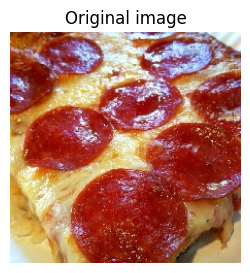

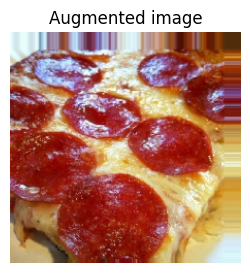

In [ ]:
# Show original image and augmented image
import random
random_number = random.randrange(len(images)) # random.randint(0, 31)
print(f"showing image number: {random_number}")
plt.figure(figsize=(3, 3))
plt.imshow(images[random_number])
plt.title("Original image")
plt.axis("off")
plt.show()
plt.figure(figsize=(3, 3))
plt.imshow(augmented_images[random_number])
plt.title("Augmented image")
plt.axis("off")
plt.show()

In [ ]:
print("Filepath:", train_data.filepaths[random_number])

Filepath: pizza_steak/train/pizza/1029698.jpg


Now we've seen what augmented training data looks like, let's build a model and see how it learns.

In [ ]:
# Create a model (same as model_5)
model_6 = Sequential([
    Conv2D(10, 3, activation="relu", input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=2),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# Compile the model
model_6.compile(
    loss="binary_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

# Fit the model
history_6 = model_6.fit(
    train_data_augmented, # augmented
    epochs=5,
    steps_per_epoch=len(train_data_augmented),
    validation_data=test_data,
    validation_steps=len(test_data)
)

In [ ]:
# Chek our models training curves
plot_loss_curves(history_6)

Let's suffle our augmented training data and train another model (the same as before) and see what will happen.

In [ ]:
# Import data and augment it and shuffle from training directory
train_data_augmented_shuffled = train_datagen.flow_from_directory(train_dir,
                                                                  target_size=(224, 224),
                                                                  class_mode="binary",
                                                                  batch_size=32,
                                                                  shuffle=True) #shuffle this time


Found 1500 images belonging to 2 classes.


In [ ]:
model_7 = Sequential([
    Conv2D(10, 3, activation="relu", input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=2),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# Compile the model
model_7.compile(
    loss="binary_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

# Fit the model
history_7 = model_7.fit(
    train_data_augmented_shuffled, #shuffled training one
    epochs=5,
    steps_per_epoch=len(train_data_augmented_shuffled),
    validation_data=test_data,
    validation_steps=len(test_data))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6980 - loss: 0.6047 - val_accuracy: 0.6900 - val_loss: 0.5444
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.7760 - loss: 0.4885 - val_accuracy: 0.8160 - val_loss: 0.4284
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8000 - loss: 0.4401 - val_accuracy: 0.8280 - val_loss: 0.3944
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8173 - loss: 0.4249 - val_accuracy: 0.8380 - val_loss: 0.3635
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8333 - loss: 0.3899 - val_accuracy: 0.8640 - val_loss: 0.3238


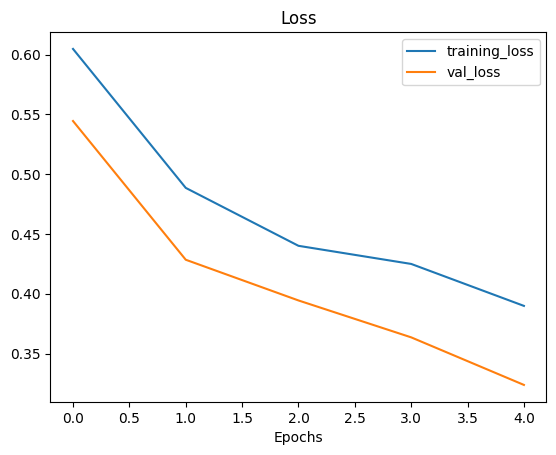

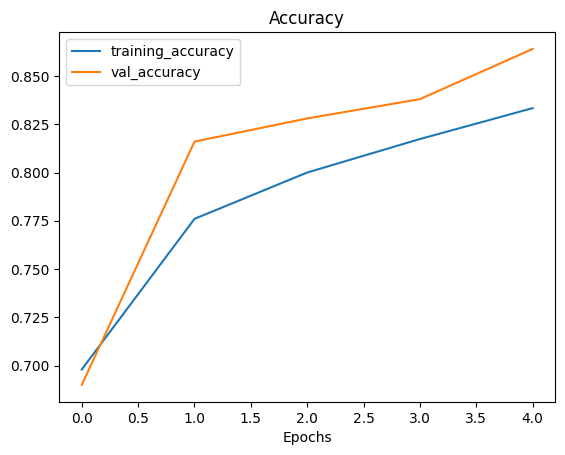

In [ ]:
plot_loss_curves(history_7)

🦭 **Note :** When shuffling training data, the model gets exposed to all different kinds of data during training, thus enabling it to learn features across a wide array of images (in our case, pizza & steak at the same time instead of just pizza then steak).

### 7. Repeat untill satisfied

Since we've already beaten our baseline, there are a few things we could try to continue to improve our model:

* Increase the number of model layers (e.g. add more `Conv2D` / `MaxPool2D` layers)  
* Increase the number of filters in each convolutional layer (e.g. from 10 to 31 or even 64 etc.)  
* Train for longer (more epochs)  
* Find an ideal learning rate  
* Get more data (give to model more opportunities to learn)  
* Use **transfer learning** to leverage what another image model has learn and adjust it for our own use case  


## Making a prediction with our trained model on own custom data

In [ ]:
print(class_names)

['pizza' 'steak']


In [ ]:
import matplotlib.image as mpimg
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg



--2026-05-24 20:48:00--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg’

03-steak.jpeg       100%[===================>]   1.89M  --.-KB/s    in 0.06s   

2026-05-24 20:48:00 (32.5 MB/s) - ‘03-steak.jpeg’ saved [1978213/1978213]



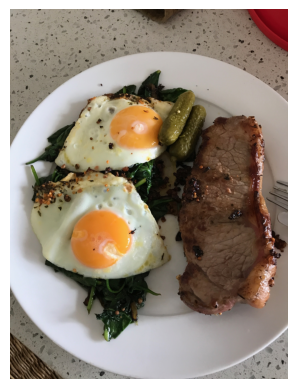

In [ ]:
steak = mpimg.imread("03-steak.jpeg")
plt.imshow(steak)
plt.axis(False);

In [ ]:
# Check the shape of our image
steak.shape

(4032, 3024, 3)

In [ ]:
steak

array([[[162, 158, 149],
        [163, 159, 150],
        [166, 162, 153],
        ...,
        [136,  17,  23],
        [140,  21,  27],
        [140,  21,  27]],

       [[164, 160, 151],
        [164, 160, 151],
        [164, 160, 151],
        ...,
        [133,  14,  20],
        [134,  15,  21],
        [137,  18,  24]],

       [[166, 162, 153],
        [165, 161, 152],
        [163, 159, 150],
        ...,
        [136,  17,  23],
        [134,  15,  21],
        [136,  17,  23]],

       ...,

       [[154, 132, 111],
        [142, 121, 100],
        [101,  80,  59],
        ...,
        [164, 155, 148],
        [152, 141, 135],
        [140, 129, 123]],

       [[141, 119,  96],
        [138, 118,  94],
        [106,  85,  64],
        ...,
        [158, 147, 141],
        [142, 131, 125],
        [138, 127, 121]],

       [[148, 126, 102],
        [148, 128, 103],
        [114,  93,  72],
        ...,
        [153, 142, 136],
        [138, 127, 121],
        [143, 132, 126]]

In [ ]:
tf.expand_dims(steak, axis=0).shape

TensorShape([1, 4032, 3024, 3])

⚓**Note :** When you train a neural network and you want to make a prediction with it on your own custom data, it's important that your custom data or new data is preprocessed into the same format as the data your model was trained on.

In [ ]:
steak = tf.image.resize(steak, size=[224, 224])
steak.shape

In [ ]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
  """
  Reads an image file and turns it into a tensor with RGB channels (3).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)
  #Decode the read file into a tensor
  img = tf.image.decode_image(img, channels=3, expand_animations=False)
  img.set_shape([None, None, 3])
  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size=[img_shape, img_shape])
  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
steak = load_and_prep_image("03-steak.jpeg")

In [ ]:
steak

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.6377451 , 0.6220588 , 0.57892156],
        [0.6504902 , 0.63186276, 0.5897059 ],
        [0.63186276, 0.60833335, 0.5612745 ],
        ...,
        [0.52156866, 0.05098039, 0.09019608],
        [0.49509802, 0.04215686, 0.07058824],
        [0.52843136, 0.07745098, 0.10490196]],

       [[0.6617647 , 0.6460784 , 0.6107843 ],
        [0.6387255 , 0.6230392 , 0.57598037],
        [0.65588236, 0.63235295, 0.5852941 ],
        ...,
        [0.5352941 , 0.06862745, 0.09215686],
        [0.529902  , 0.05931373, 0.09460784],
        [0.5142157 , 0.05539216, 0.08676471]],

       [[0.6519608 , 0.6362745 , 0.5892157 ],
        [0.6392157 , 0.6137255 , 0.56764704],
        [0.65637255, 0.6269608 , 0.5828431 ],
        ...,
        [0.53137255, 0.06470589, 0.08039216],
        [0.527451  , 0.06862745, 0.1       ],
        [0.52254903, 0.05196078, 0.0872549 ]],

       ...,

       [[0.49313724, 0.42745098, 0.31029412],
        [0.05

In [ ]:
pred = model_7.predict(tf.expand_dims(steak, axis=0))
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[0.9433867]], dtype=float32)

Looks like our custom image is being put through our model, however, it currently outputs a prediction probability, wouldn't it be nice if we could visualize the image as well as the model's prediction.

In [ ]:
# Remind ourselves of our class names
class_names

array(['pizza', 'steak'], dtype='<U5')

In [ ]:
"""
We can index the predicted class by rounding the prediction probability and
indexing it on its class names.
"""
pred_class = class_names[int(tf.round(pred))]
pred_class

np.str_('steak')

In [ ]:
def pred_and_plot(model, filename, class_names=class_names):
  """
  Imports an image located at filename, makes a prediction on it with
  a trained model and plots the image with the predicted class as the title.
  """
  img = load_and_prep_image(filename)

  pred = model.predict(tf.expand_dims(img, axis=0))
  pred_class = class_names[int(tf.round(pred))]

  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


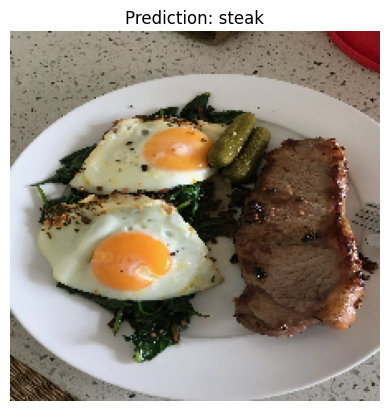

In [ ]:
pred_and_plot(model_7, "03-steak.jpeg")

In [ ]:
!wget https://d17wu0fn6x6rgz.cloudfront.net/img/w/tarif/mgt/pizza_14_11zon.webp


--2026-05-24 21:16:25--  https://d17wu0fn6x6rgz.cloudfront.net/img/w/tarif/mgt/pizza_14_11zon.webp
Resolving d17wu0fn6x6rgz.cloudfront.net (d17wu0fn6x6rgz.cloudfront.net)... 3.163.109.137, 3.163.109.81, 3.163.109.69, ...
Connecting to d17wu0fn6x6rgz.cloudfront.net (d17wu0fn6x6rgz.cloudfront.net)|3.163.109.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 566268 (553K) [application/octet-stream]
Saving to: ‘pizza_14_11zon.webp’

pizza_14_11zon.webp 100%[===================>] 553.00K  1.50MB/s    in 0.4s    

2026-05-24 21:16:25 (1.50 MB/s) - ‘pizza_14_11zon.webp’ saved [566268/566268]



In [ ]:
pizza =load_and_prep_image("pizza_14_11zon.webp")

In [ ]:
pizza.shape

TensorShape([1, 224, 224, 3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


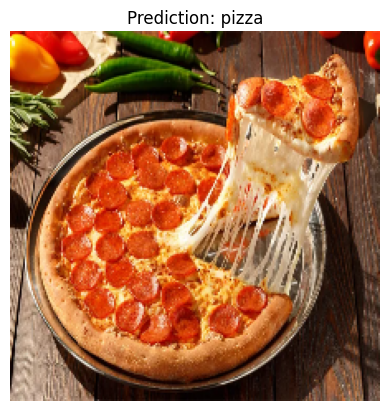

In [ ]:
pred_and_plot(model_7, "pizza_14_11zon.webp")

⛄ I did it, yeeeeees :)